In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
def load_boston_housing_data():
    
    # Load CSV file (make sure file is in same folder)
    df = pd.read_csv("HousingData.csv")

    # Handle missing values (important for this dataset)
    df = df.fillna(df.mean())

    # Split features and target
    X = df.iloc[:, :-1].values   # all columns except last
    y = df.iloc[:, -1].values    # last column (MEDV)

    # Normalize data
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X = scaler_X.fit_transform(X)
    y = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

    return X, y, scaler_y


# Load data
X, y, scaler_y = load_boston_housing_data()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


# Convert to float32 (important)
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')

y_train = y_train.astype('float32')
y_val = y_val.astype('float32')
y_test = y_test.astype('float32')

In [4]:
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(buffer_size=len(X_train)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),  # dynamic input

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1)  # Linear output (regression)
])


# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=10,
        min_lr=0.00001,
        verbose=1
    )
]


In [7]:
history = model.fit(
    train_dataset,
    epochs=200,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 1.7520 - mae: 0.9305 - val_loss: 0.7320 - val_mae: 0.6097 - learning_rate: 0.0010
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.8220 - mae: 0.6493 - val_loss: 0.5968 - val_mae: 0.5464 - learning_rate: 0.0010
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4610 - mae: 0.4966 - val_loss: 0.5459 - val_mae: 0.5294 - learning_rate: 0.0010
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3596 - mae: 0.4409 - val_loss: 0.5175 - val_mae: 0.5281 - learning_rate: 0.0010
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3128 - mae: 0.4171 - val_loss: 0.4835 - val_mae: 0.5132 - learning_rate: 0.0010
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2731 - mae: 0.3821 - val_loss: 0.4626 - val_mae: 0.5000 - learning_rate: 0.0010
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2492 - mae: 0.3794 - val_loss: 0.4510 - val_mae: 0.4931 - learning_rate: 0.0010
Epoch 

In [8]:
test_loss, test_mae = model.evaluate(test_dataset)

print("\nTest Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2431 - mae: 0.3442 

Test Loss (MSE): 0.24314959347248077
Test MAE: 0.3442215621471405


In [9]:
predictions = model.predict(test_dataset)

# Convert back to original scale
predictions_rescaled = scaler_y.inverse_transform(predictions)
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

print("\nSample Predictions:")
for i in range(5):
    print(f"Predicted: {predictions_rescaled[i][0]:.2f}, Actual: {y_test_rescaled[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

Sample Predictions:
Predicted: 27.15, Actual: 23.60
Predicted: 38.34, Actual: 32.40
Predicted: 16.38, Actual: 13.60
Predicted: 25.30, Actual: 22.80
Predicted: 14.85, Actual: 16.10


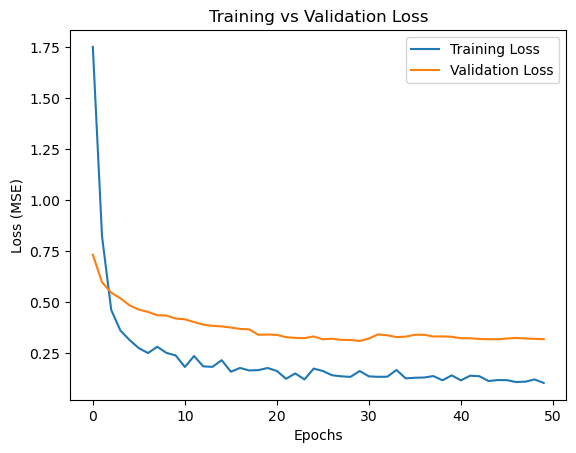

In [12]:

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

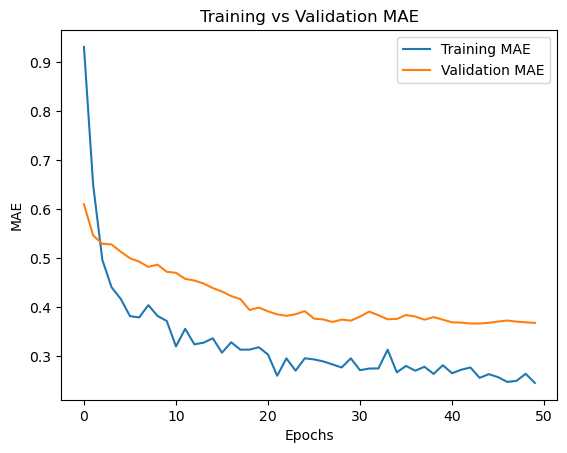

In [13]:
plt.figure()
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.show()